In [1]:
from google.colab import files
uploaded = files.upload()

Saving mao_b_ic50.csv to mao_b_ic50.csv


In [2]:
!pip install pandas matplotlib seaborn rdkit scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.9/34.9 MB 54.9 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from rdkit.Chem import Descriptors
import matplotlib.pyplot as plt
import seaborn as sns


In [26]:
df = pd.read_csv("mao_b_ic50.csv")
print(df.shape)
df.head()

(3247, 3)


,Unnamed: 0,smiles,ic50
0,0,Cc1cc2c(nn1)-c1cc(OCCCC(F)(F)F)ccc1C2=O,0.014
1,1,C#CCN(C)[C@H](C)Cc1ccccc1,0.017
2,2,O=C(O)c1coc2ccccc2c1=O,0.048
3,3,Cc1ccc2oc(=O)c(-c3cccc(Br)c3)cc2c1,0.134
4,4,O=C(Nc1ccc(Cl)c(Cl)c1)c1ccc2[nH]ccc2c1,0.227


In [27]:
df.tail()

,Unnamed: 0,smiles,ic50
3242,3242,C1=CCN(Cc2ccccc2)CC1,6536800.0
3243,3243,CN(C)c1ccc(-c2nnc3c(C(=O)c4ccccc4)nc4ccccc4n23...,7300000.0
3244,3244,Oc1ccc(/C=N/Nc2nc3ccccc3nc2Cc2ccccc2)cc1,7900000.0
3245,3245,C/C(=N\Nc1nc2ccccc2nc1Cc1ccccc1)c1ccc(O)cc1,8400000.0
3246,3246,CN(Cc1ccccc1)c1ccc2nc(-c3ccccc3)oc2n1,52000000.0


In [34]:
# Keep only the required columns and drop rows with NaNs
df = df[['smiles', 'ic50']].dropna()

# Drop duplicates
df.drop_duplicates(inplace=True)

# Filter out standard_value >= 1,000,000 (outliers) AND standard_value <= 0 (invalid for log)
df = df[(df['ic50'] < 10_000) & (df['ic50'] > 0)]

# Add log(IC50)
df['log_ic50'] = np.log10(df['ic50'])

In [29]:
df = df[['smiles', 'ic50']]

In [35]:
df.head()

,smiles,ic50,log_ic50
0,Cc1cc2c(nn1)-c1cc(OCCCC(F)(F)F)ccc1C2=O,0.014,-1.853872
1,C#CCN(C)[C@H](C)Cc1ccccc1,0.017,-1.769551
2,O=C(O)c1coc2ccccc2c1=O,0.048,-1.318759
3,Cc1ccc2oc(=O)c(-c3cccc(Br)c3)cc2c1,0.134,-0.872895
4,O=C(Nc1ccc(Cl)c(Cl)c1)c1ccc2[nH]ccc2c1,0.227,-0.643974


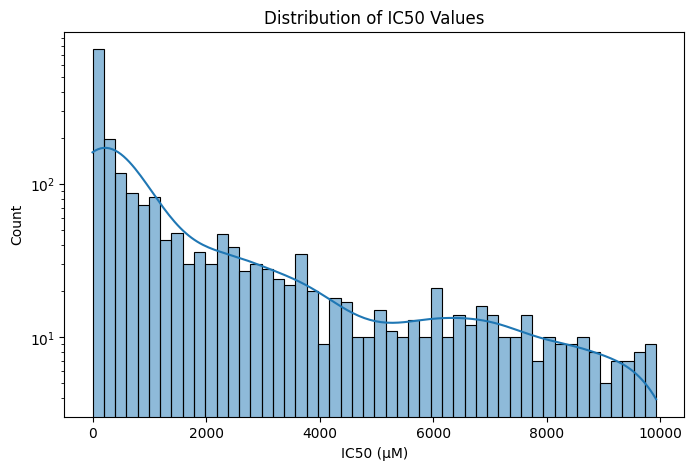

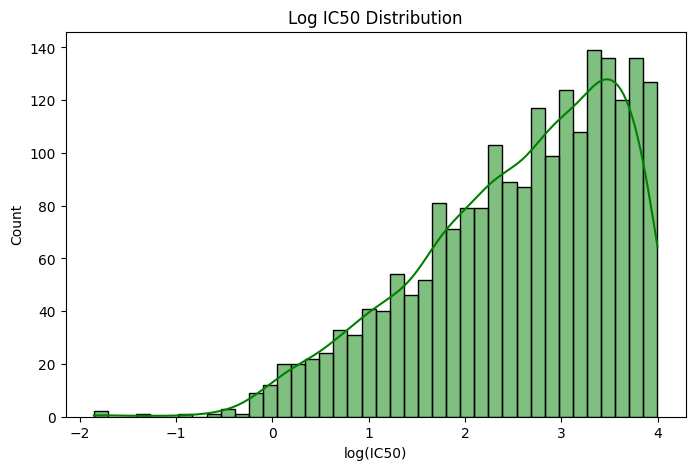

In [36]:
plt.figure(figsize=(8, 5))
sns.histplot(df['ic50'], bins=50, kde=True)
plt.title('Distribution of IC50 Values')
plt.xlabel('IC50 (µM)')
plt.yscale('log')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df['log_ic50'], bins=40, kde=True, color='green')
plt.title('Log IC50 Distribution')
plt.xlabel('log(IC50)')
plt.show()

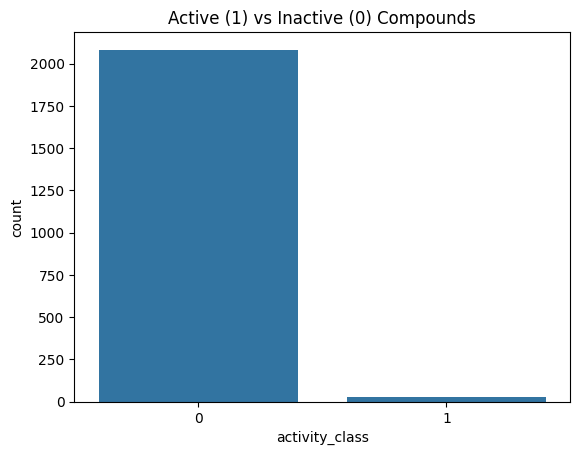

In [37]:
# Threshold at 1000 nM
df['activity_class'] = df['ic50'].apply(lambda x: 1 if x <= 1 else 0)

sns.countplot(x='activity_class', data=df)
plt.title('Active (1) vs Inactive (0) Compounds')
plt.show()

In [38]:
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return {
            'MolWt': Descriptors.MolWt(mol),
            'LogP': Descriptors.MolLogP(mol),
            'NumHDonors': Descriptors.NumHDonors(mol),
            'NumHAcceptors': Descriptors.NumHAcceptors(mol)
        }
    else:
        return {
            'MolWt': None,
            'LogP': None,
            'NumHDonors': None,
            'NumHAcceptors': None
        }

descriptor_df = df['smiles'].apply(compute_descriptors)
desc_df = pd.DataFrame(descriptor_df.tolist())
df = pd.concat([df, desc_df], axis=1)

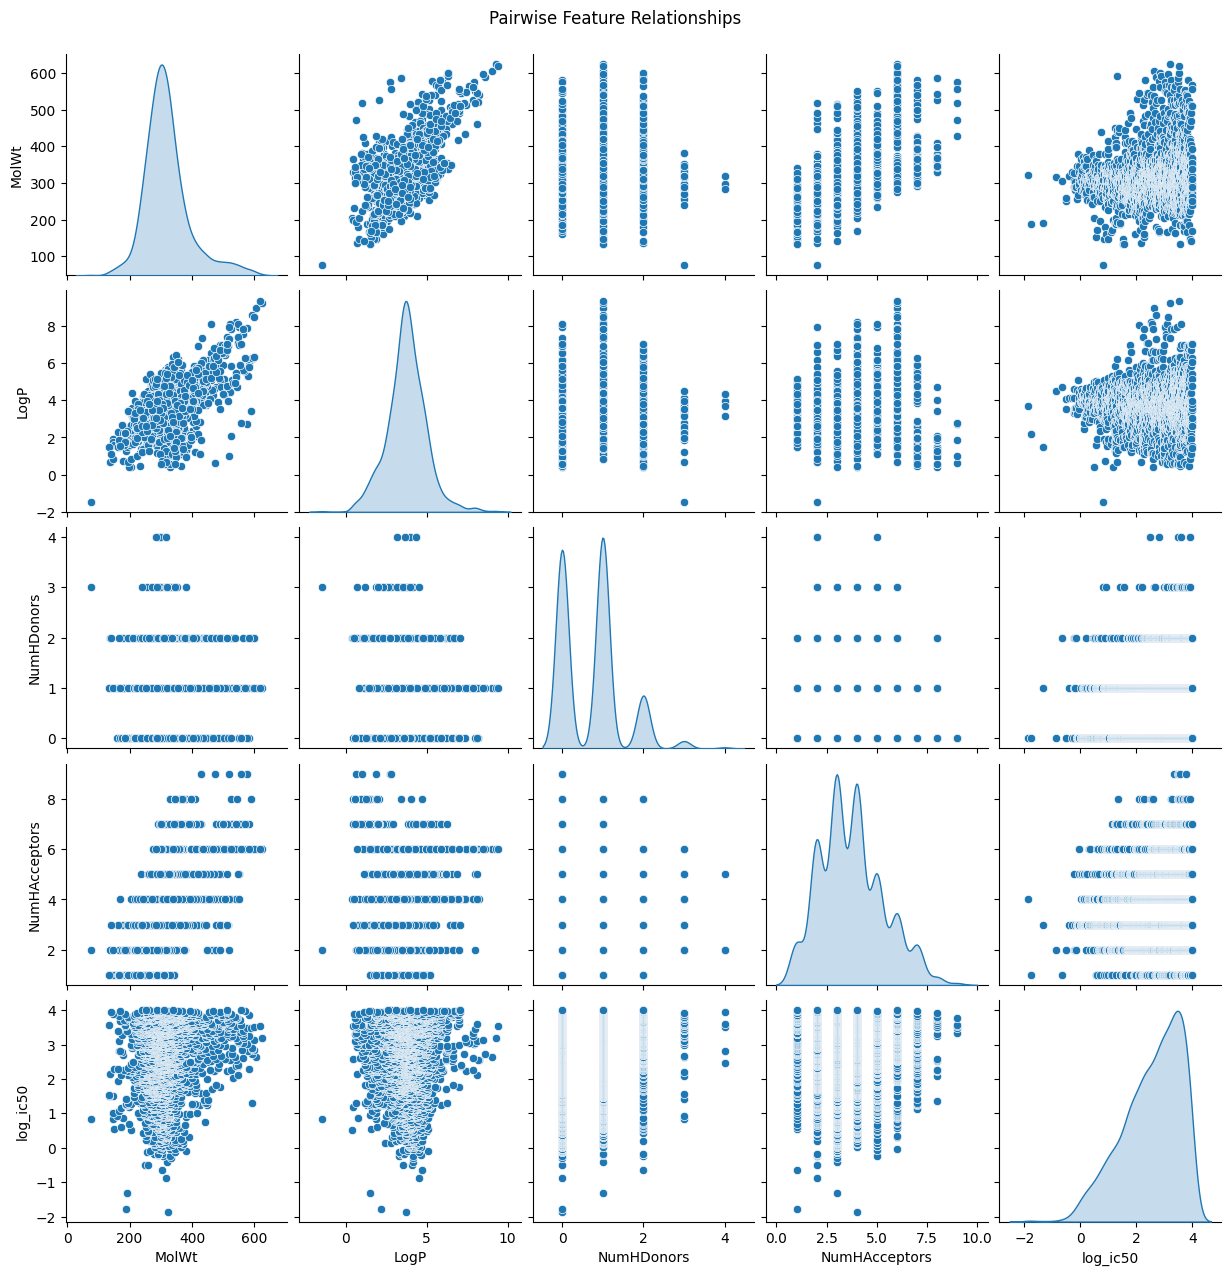

In [39]:
sns.pairplot(df[['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'log_ic50']], diag_kind='kde')
plt.suptitle("Pairwise Feature Relationships", y=1.02)
plt.show()

In [40]:
print("NaNs after descriptor generation:")
print(df[['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors']].isna().sum())
# Drop rows with any NaN in the descriptor columns
df.dropna(subset=['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'log_ic50'], inplace=True)

NaNs after descriptor generation:
MolWt            0
LogP             0
NumHDonors       0
NumHAcceptors    0
dtype: int64


In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

features = ['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors']
X = df[features]
y = df['log_ic50']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("RMSE:", rmse)

R² Score: 0.1969750104689031
RMSE: 0.9112759299685314
